In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
# Load saved model
with open('../models/xgboost_order_model.pkl', 'rb') as f:
    saved = pickle.load(f)

model        = saved['model']
FEATURE_COLS = saved['feature_cols']
THRESHOLD    = saved['threshold']

print(f'Model loaded. Default threshold: {THRESHOLD}')

# Load feature data
grid = pd.read_parquet('../processed/retailer_day_features.parquet')
grid['date'] = pd.to_datetime(grid['date'])
print(f'Feature data loaded: {grid.shape}')

Model loaded. Default threshold: 0.4
Feature data loaded: (1304640, 27)


In [3]:
# Change this to the date you want predictions for
TARGET_DATE = grid['date'].max()  # Last date in data

print(f'Generating predictions for: {TARGET_DATE.date()}')

day_data = grid[grid['date'] == TARGET_DATE].copy()
print(f'Retailers to score: {len(day_data):,}')

Generating predictions for: 2026-05-31
Retailers to score: 8,640


In [4]:
X_score = day_data[FEATURE_COLS].values
day_data['order_probability'] = model.predict_proba(X_score)[:, 1]
day_data['will_order'] = (day_data['order_probability'] >= THRESHOLD).astype(int)

print(f'Retailers flagged to call (prob >= {THRESHOLD}): {day_data["will_order"].sum():,}')
print(f'Retailers to skip: {(day_data["will_order"]==0).sum():,}')
print(f'Estimated call reduction: {(1 - day_data["will_order"].mean())*100:.1f}%')

Retailers flagged to call (prob >= 0.4): 82
Retailers to skip: 8,558
Estimated call reduction: 99.1%


In [6]:
# Load raw data to get retailer names/details for the output
raw = pd.read_csv("../data/Jan - May '26 Data.csv")
raw['createdAt'] = pd.to_datetime(raw['createdAt'], dayfirst=True)

# Get last known order date per retailer
confirmed = raw[raw['orderStatus'].isin(['Delivered','PartiallyDelivered'])]
orders = confirmed.drop_duplicates(subset='orderNumber')[['customerId','createdAt','hubName','shopType','retailerType','orderSource']]
last_order = orders.groupby('customerId').agg(
    last_order_date  = ('createdAt', 'max'),
    total_orders     = ('createdAt', 'count'),
    hub              = ('hubName', lambda x: x.mode()[0]),
    shop_type        = ('shopType', lambda x: x.mode()[0]),
    retailer_type    = ('retailerType', lambda x: x.mode()[0] if x.notna().any() else 'Unknown'),
    primary_source   = ('orderSource', lambda x: x.mode()[0])
).reset_index()

print('Retailer details loaded.')

Retailer details loaded.


In [7]:
# Merge probability scores with retailer info
priority_list = day_data[['customerId','order_probability','will_order',
                           'days_since_last_order','orders_last_7_days',
                           'avg_gap_between_orders','days_overdue']].merge(
    last_order, on='customerId', how='left'
)

# Sort by probability descending
priority_list = priority_list.sort_values('order_probability', ascending=False).reset_index(drop=True)
priority_list.index += 1  # rank starts at 1
priority_list.index.name = 'rank'

# Format for readability
priority_list['order_probability_pct'] = (priority_list['order_probability'] * 100).round(1).astype(str) + '%'
priority_list['last_order_date'] = priority_list['last_order_date'].dt.date
priority_list['avg_gap_between_orders'] = priority_list['avg_gap_between_orders'].round(1)
priority_list['days_overdue'] = priority_list['days_overdue'].round(1)

# Final output columns
output_cols = [
    'customerId', 'hub', 'shop_type', 'retailer_type',
    'order_probability_pct', 'will_order',
    'last_order_date', 'days_since_last_order',
    'avg_gap_between_orders', 'days_overdue',
    'orders_last_7_days', 'total_orders', 'primary_source'
]

output = priority_list.reset_index()[['rank'] + output_cols]
print(f'Priority list shape: {output.shape}')
print()
print('=== TOP 20 RETAILERS TO CALL TOMORROW ===')
output.head(20)

Priority list shape: (8640, 14)

=== TOP 20 RETAILERS TO CALL TOMORROW ===


,rank,customerId,hub,shop_type,retailer_type,order_probability_pct,will_order,last_order_date,days_since_last_order,avg_gap_between_orders,days_overdue,orders_last_7_days,total_orders,primary_source
0,1,USR-163848,Rapid Enterprises,Paan C,HVHF,65.7%,1,2026-05-27,4.0,1.8,2.0,3.0,83,App
1,2,USR-162163,Rapid Enterprises,General C,HVHF,64.7%,1,2026-05-29,2.0,1.7,0.0,5.0,86,App
2,3,USR-165609,Rapid Enterprises,General B,HVHF,64.4%,1,2026-05-29,2.0,1.9,0.0,3.0,79,App
3,4,USR-166068,Rapid Enterprises,General B,HVHF,63.7%,1,2026-05-28,3.0,1.4,1.0,4.0,78,App
4,5,USR-169217,Rapid Enterprises,General C,HVHF,63.4%,1,2026-05-28,3.0,1.7,1.0,2.0,86,App
5,6,USR-166444,Rapid Enterprises,General B,HVHF,62.6%,1,2026-05-28,3.0,2.3,0.0,2.0,64,App
6,7,USR-172181,Instant Foods (Mathura),General B,HVLF,60.7%,1,2026-05-31,2.0,2.0,0.0,1.0,2,App
7,8,USR-165608,Rapid Enterprises,General B,HVHF,59.4%,1,2026-05-29,2.0,1.9,0.0,3.0,80,App
8,9,USR-166614,Rapid Enterprises,General B,HVHF,57.2%,1,2026-05-28,3.0,2.3,0.0,4.0,66,App
9,10,USR-166604,Rapid Enterprises,General A,HVHF,56.1%,1,2026-05-27,4.0,2.5,1.0,2.0,60,App


In [8]:
date_str = TARGET_DATE.strftime('%Y-%m-%d')
output_path = f'../outputs/call_priority_{date_str}.csv'

output.to_csv(output_path, index=False)
print(f'Priority list saved to: {output_path}')
print(f'Total retailers in list: {len(output):,}')
print(f'Retailers flagged to call: {output["will_order"].sum():,}')

Priority list saved to: ../outputs/call_priority_2026-05-31.csv
Total retailers in list: 8,640
Retailers flagged to call: 82


In [9]:
call_list  = output[output['will_order'] == 1]
skip_list  = output[output['will_order'] == 0]

print('='*50)
print(f'DAILY CALL PRIORITIZATION — {date_str}')
print('='*50)
print(f'Total retailers: {len(output):,}')
print(f'Recommended to CALL: {len(call_list):,}')
print(f'Recommended to SKIP: {len(skip_list):,}')
print(f'Call volume reduction: {(1 - len(call_list)/len(output))*100:.1f}%')
print()
print('--- Call List Breakdown ---')
print(call_list.groupby('hub')['customerId'].count().sort_values(ascending=False).head(10))
print()
print('--- Top 10 High Probability Retailers ---')
print(call_list[['customerId','hub','shop_type','order_probability_pct','days_since_last_order']].head(10).to_string(index=False))

DAILY CALL PRIORITIZATION — 2026-05-31
Total retailers: 8,640
Recommended to CALL: 82
Recommended to SKIP: 8,558
Call volume reduction: 99.1%

--- Call List Breakdown ---
hub
Rapid Enterprises                33
Instant Foods(Noida)             29
Cross Line Events (EDelhi)        7
Instant Foods (SED)               3
NB Enterprises (West Delhi)       3
Cross Line Events (Ghaziabad)     2
Maa Sharda(LKO)                   2
Instant Foods (Mathura)           1
Crossline Events (Noida)          1
Instant Foods (GZB)               1
Name: customerId, dtype: int64

--- Top 10 High Probability Retailers ---
customerId                     hub shop_type order_probability_pct  days_since_last_order
USR-163848       Rapid Enterprises    Paan C                 65.7%                    4.0
USR-162163       Rapid Enterprises General C                 64.7%                    2.0
USR-165609       Rapid Enterprises General B                 64.4%                    2.0
USR-166068       Rapid Enterpri

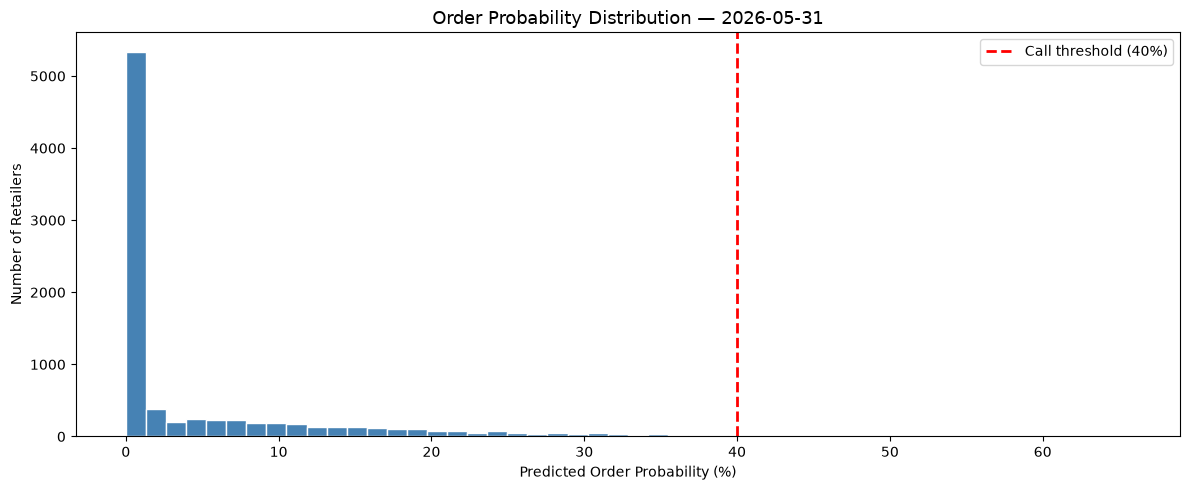

In [10]:
import matplotlib.pyplot as plt

# Probability distribution of all retailers
plt.figure(figsize=(12, 5))
plt.hist(output['order_probability_pct'].str.replace('%','').astype(float),
         bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=THRESHOLD*100, color='red', linestyle='--', lw=2,
            label=f'Call threshold ({int(THRESHOLD*100)}%)')
plt.title(f'Order Probability Distribution — {date_str}', fontsize=13)
plt.xlabel('Predicted Order Probability (%)')
plt.ylabel('Number of Retailers')
plt.legend()
plt.tight_layout()
plt.show()